# 🧠 EX59: โหมดการทำงานหลายภารกิจ (Multi-Task Modes)

YOLO11 แชร์ Backbone+Neck เดียวกัน เฉพาะ prediction Head ต่างกัน

| ภารกิจ | นามสกุล | แอตทริบิวต์ | ตัวอย่างการใช้ |
|--------|--------|------------|--------------|
| Detect | `.pt` | `.boxes` | นับยานพาหนะ |
| Segment | `-seg.pt` | `.masks` | วัดพื้นที่ทางการแพทย์ |
| Classify | `-cls.pt` | `.probs` | จำแนกของเสีย |
| Pose | `-pose.pt` | `.keypoints` | วิเคราะห์ท่าทางกีฬา |
| OBB | `-obb.pt` | `.obb` | ภาพดาวเทียม |

**ลำดับต้นทุน:** Classify < Detect < Pose < OBB ≈ Segment

## 🔗 ลิงก์
- [[EX58_Model_Export_TH]] | [[EX60_Streaming_Inference_TH]]


/home/luke/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


[INFO] ใช้อุปกรณ์: 0

--- เริ่มการตรวจสอบ ---

[DETECT]


  สรุป: boxes=1

[SEGMENT]


Found https://static.independent.co.uk/2021/05/20/13/GettyImages-1345073.jpg locally at GettyImages-1345073.jpg


  สรุป: masks=มี

[CLASSIFY]


Found https://static.independent.co.uk/2021/05/20/13/GettyImages-1345073.jpg locally at GettyImages-1345073.jpg


  สรุป: top1=981 conf=0.419

[POSE]


Found https://static.independent.co.uk/2021/05/20/13/GettyImages-1345073.jpg locally at GettyImages-1345073.jpg


  สรุป: kp=torch.Size([1, 17, 2])


--- สิ้นสุดการตรวจสอบ ---


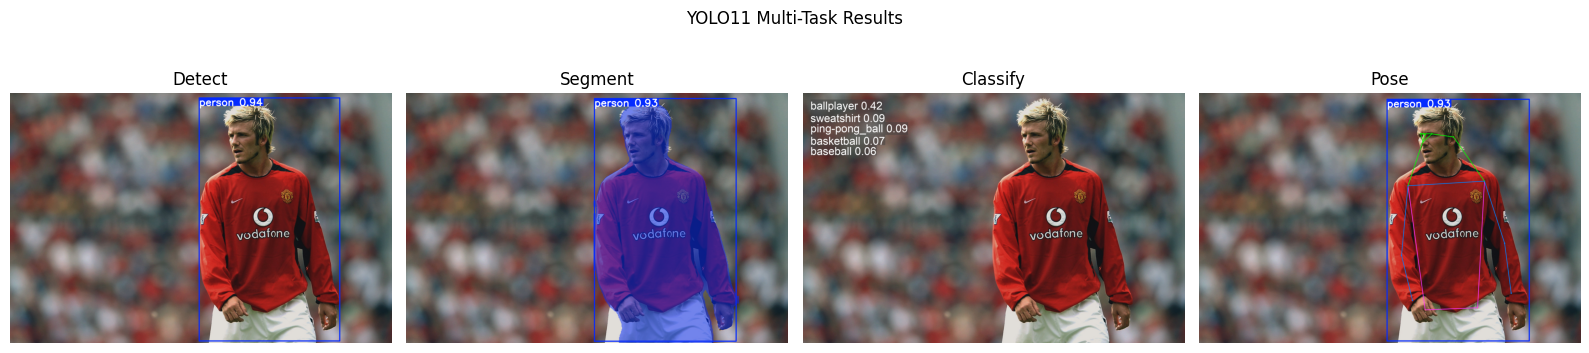

In [1]:
# Back up or checkpoint this section of code before starting to modify the large file.
import gc
import cv2, numpy as np, torch
import matplotlib.pyplot as plt
from solution import get_yolo_model_by_task
%matplotlib inline

device = "0" if torch.cuda.is_available() else "cpu"
print(f"[INFO] ใช้อุปกรณ์: {device}")

img_url = 'https://static.independent.co.uk/2021/05/20/13/GettyImages-1345073.jpg'

tasks = {
    "detect":   lambda r: f"boxes={len(r.boxes)}",
    "segment":  lambda r: f"masks={'มี' if r.masks else 'None'}",
    "classify": lambda r: f"top1={r.probs.top1} conf={r.probs.top1conf.item():.3f}",
    "pose":     lambda r: f"kp={r.keypoints.xy.shape if r.keypoints else 'None'}",
}

print("\n--- เริ่มการตรวจสอบ ---")
results_map = {}
for task, summarize in tasks.items():
    print(f"\n[{task.upper()}]")
    model = get_yolo_model_by_task(task)
    res = model.predict(source=img_url, verbose=False)
    results_map[task] = res[0]
    print(f"  สรุป: {summarize(res[0])}")
    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
print("--- สิ้นสุดการตรวจสอบ ---")

fig, axes = plt.subplots(1, len(results_map), figsize=(4*len(results_map),4))
for ax,(task,result) in zip(axes, results_map.items()):
    ax.imshow(cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB))
    ax.set_title(task.capitalize()); ax.axis("off")
plt.suptitle("YOLO11 Multi-Task Results"); plt.tight_layout(); plt.show()
